In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# Load the dataset
df = pd.read_csv('loan_approval_dataset.csv')

# Drop 'loan_id' as it is not needed for prediction
df.drop('loan_id', axis=1, inplace=True)

# Clean column names (remove extra spaces and convert to lowercase)
df.columns = df.columns.str.strip().str.lower()

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [3]:
# 1. Importing the required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

In [4]:
# 2. Load the data
df = pd.read_csv('loan_approval_dataset.csv')

# Drop the loan_id column
df.drop('loan_id', axis=1, inplace=True)

# Clean up column names by removing extra spaces and making them lowercase
df.columns = df.columns.str.strip().str.lower()

# Let's take a quick look at the first 5 rows
print(df.head())

   no_of_dependents      education self_employed  income_annum  loan_amount  \
0                 2       Graduate            No       9600000     29900000   
1                 0   Not Graduate           Yes       4100000     12200000   
2                 3       Graduate            No       9100000     29700000   
3                 3       Graduate            No       8200000     30700000   
4                 5   Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value loa

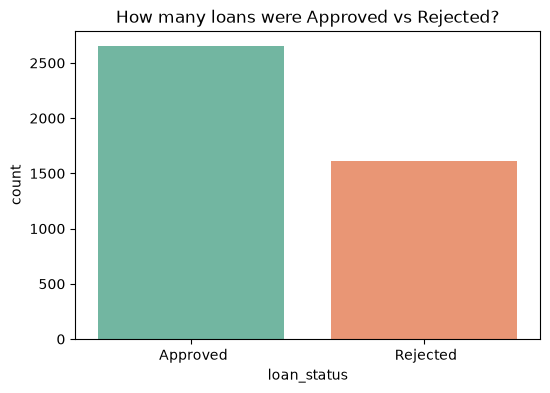

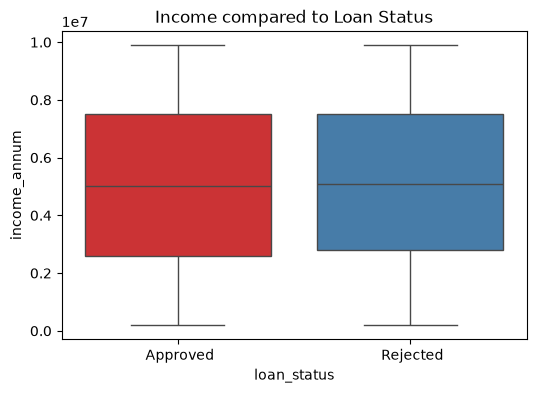

In [6]:
# Step-2 EDA
# 3. Let's see how many loans were approved vs rejected
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, hue='loan_status', legend=False, palette="Set2")
plt.title("How many loans were Approved vs Rejected?")
plt.show()

# Let's check how income affects loan approval
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='income_annum', data=df, hue='loan_status', legend=False, palette="Set1")
plt.title("Income compared to Loan Status")
plt.show()

In [7]:
# 4. Convert text categories into numbers (0s and 1s)
le = LabelEncoder()
for col in ['education', 'self_employed', 'loan_status']:
    df[col] = le.fit_transform(df[col])

# Create a smart new feature: Debt-to-Income Ratio
df['debt to imcome ratio'] = df['loan_amount'] / df['income_annum']

# Create another feature: Total Assets
df['total_assets'] = (df['residential_assets_value'] + 
                      df['commercial_assets_value'] + 
                      df['luxury_assets_value'] + 
                      df['bank_asset_value'])

In [11]:
# 5. Define what we use to predict (X) and what we are predicting (y)
feature_cols = [
    'no_of_dependents', 'education', 'self_employed', 'income_annum',
    'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 
    'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 
    'debt to imcome ratio', 'total_assets'
]

X = df[feature_cols]
y = df['loan_status']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18, stratify=y)

# Scale the numbers so they are on a level playing field
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# 6. Build the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

# Let the model learn from the training data
log_reg.fit(X_train, y_train)

# Now ask the model to predict outcomes for our hidden test data
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

Accuracy:  0.927400468384075
ROC-AUC Score:  0.9659559333694822

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       531
           1       0.88      0.94      0.91       323

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.92       854
weighted avg       0.93      0.93      0.93       854



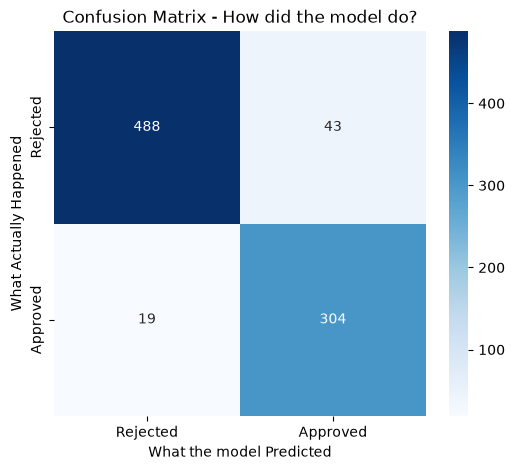

In [13]:
# 7. Print out the model's report card
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("ROC-AUC Score: ", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Draw the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"])
plt.title("Confusion Matrix - How did the model do?")
plt.xlabel("What the model Predicted")
plt.ylabel("What Actually Happened")
plt.show()